In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('/content/insurance.csv')
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [ ]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (1338, 7)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


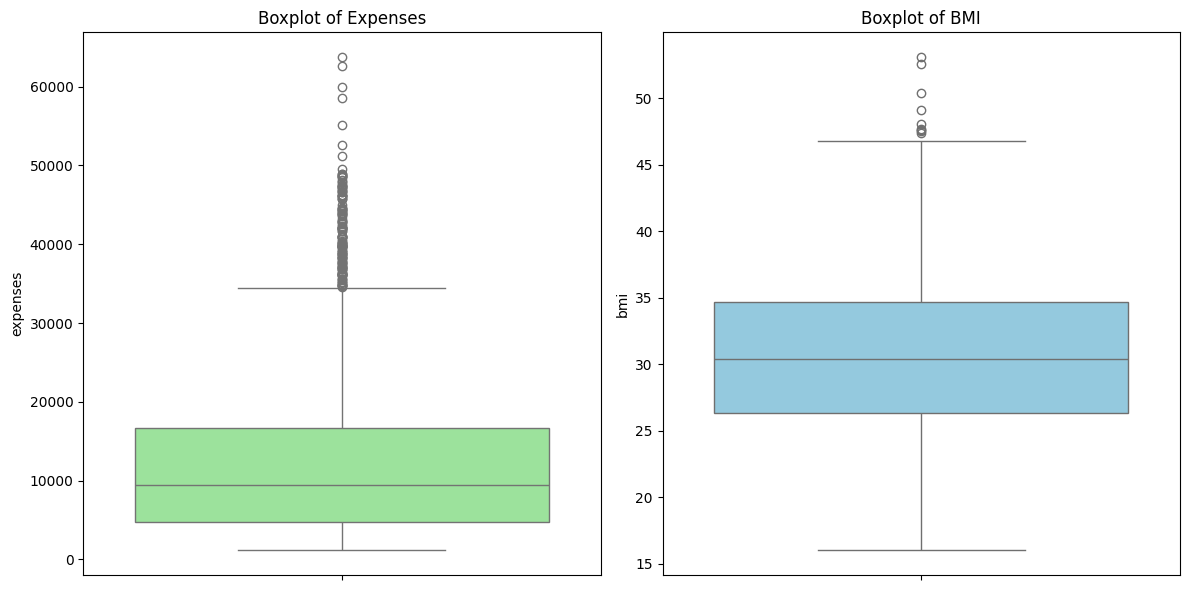

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# رسم Boxplot للمصاريف
plt.subplot(1, 2, 1)
sns.boxplot(y=df['expenses'], color='lightgreen')
plt.title('Boxplot of Expenses')

# رسم Boxplot للـ BMI
plt.subplot(1, 2, 2)
sns.boxplot(y=df['bmi'], color='skyblue')
plt.title('Boxplot of BMI')

plt.tight_layout()
plt.show()

In [ ]:

# 1. تحويل الأعمدة النصية إلى أعمدة 0 و 1
# سنقوم بتحويل: sex, smoker, region
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'])

# 2. عرض أول 5 صفوف للتأكد من النتيجة
print("--- شكل البيانات بعد التحويل ---")
print(df_encoded.head())

# 3. عرض أسماء الأعمدة الجديدة
print("\n--- الأعمدة المتوفرة الآن ---")
print(df_encoded.columns.tolist())

--- شكل البيانات بعد التحويل ---
   age   bmi  children  expenses  sex_female  sex_male  smoker_no  smoker_yes  \
0   19  27.9         0  16884.92        True     False      False        True   
1   18  33.8         1   1725.55       False      True       True       False   
2   28  33.0         3   4449.46       False      True       True       False   
3   33  22.7         0  21984.47       False      True       True       False   
4   32  28.9         0   3866.86       False      True       True       False   

   region_northeast  region_northwest  region_southeast  region_southwest  
0             False             False             False              True  
1             False             False              True             False  
2             False             False              True             False  
3             False              True             False             False  
4             False              True             False             False  

--- الأعمدة المتوفرة ال

In [ ]:
# تحويل القيم النصية إلى 0 و 1 بشكل صريح
df_final = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

print(df_final.head())

   age   bmi  children  expenses  sex_male  smoker_yes  region_northwest  \
0   19  27.9         0  16884.92         0           1                 0   
1   18  33.8         1   1725.55         1           0                 0   
2   28  33.0         3   4449.46         1           0                 0   
3   33  22.7         0  21984.47         1           0                 1   
4   32  28.9         0   3866.86         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [ ]:
# تحديد الهدف (Target)
y = df['expenses']

# تحديد الميزات (Features)
# نقوم بحذف عمود الهدف من البيانات لنحصل على الميزات فقط
X = df.drop(columns=['expenses'])

print("Target (y) shape:", y.shape)
print("Features (X) shape:", X.shape)

Target (y) shape: (1338,)
Features (X) shape: (1338, 6)


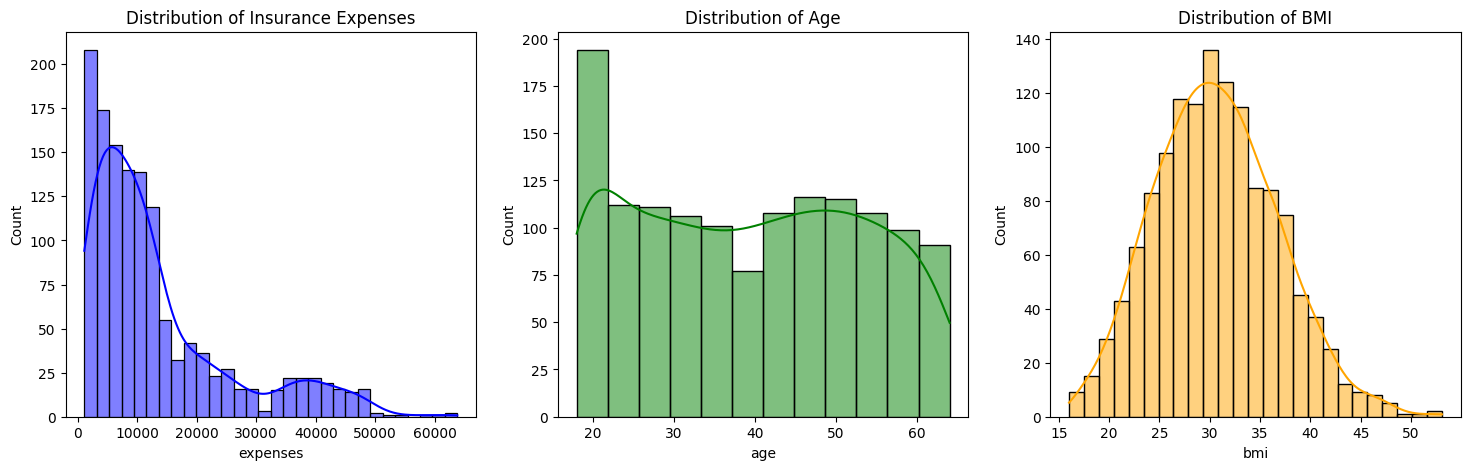

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# إعداد شكل الرسم (صف واحد فيه 3 رسومات)
plt.figure(figsize=(18, 5))

# 1. توزيع المصاريف
plt.subplot(1, 3, 1)
sns.histplot(df['expenses'], kde=True, color='blue')
plt.title('Distribution of Insurance Expenses')

# 2. توزيع العمر
plt.subplot(1, 3, 2)
sns.histplot(df['age'], kde=True, color='green')
plt.title('Distribution of Age')

# 3. توزيع كتلة الجسم
plt.subplot(1, 3, 3)
sns.histplot(df['bmi'], kde=True, color='orange')
plt.title('Distribution of BMI')

plt.show()

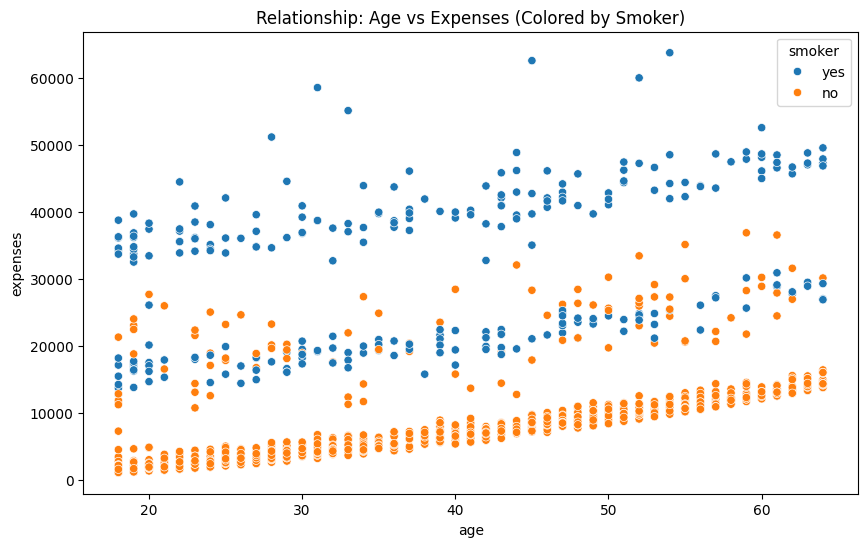

In [ ]:
plt.figure(figsize=(10, 6))
# سنرسم العمر ضد المصاريف، ونلون النقاط حسب حالة التدخين
sns.scatterplot(x='age', y='expenses', hue='smoker', data=df)
plt.title('Relationship: Age vs Expenses (Colored by Smoker)')
plt.show()

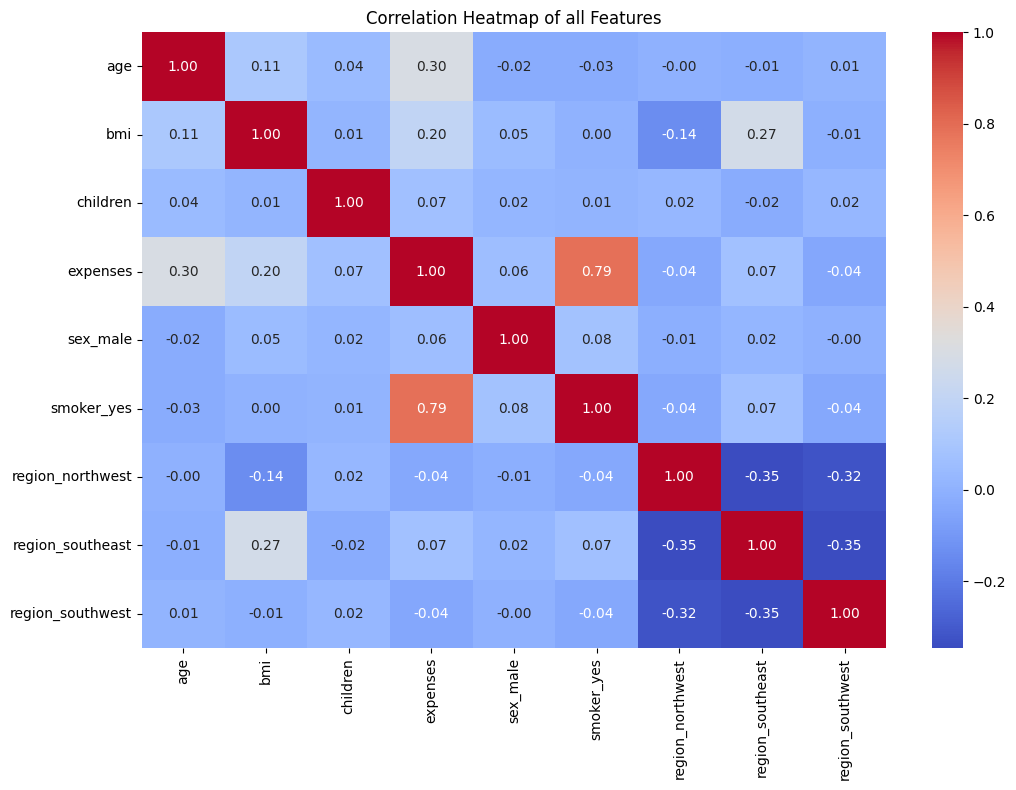

In [ ]:
plt.figure(figsize=(12, 8))
# حساب الارتباط ورسمه
correlation_matrix = df_final.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of all Features')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 1. تحديد X (الميزات) و y (الهدف) من الجدول المرمز
X = df_final.drop(columns=['expenses'])
y = df_final['expenses']

# 2. التقسيم: 80% تدريب و 20% اختبار
# random_state=42 نضع هذا الرقم لضمان الحصول على نفس التقسيم في كل مرة تشغل فيها الكود
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1070, 8)
Testing set: (268, 8)


In [ ]:
from sklearn.preprocessing import StandardScaler

# استدعاء الأداة
scaler = StandardScaler()

# "تجهيز وتحويل" بيانات التدريب (fit_transform)
# هنا السكيلر يحسب المتوسط والانحراف المعياري لبيانات التدريب ويطبقها
X_train_scaled = scaler.fit_transform(X_train)

# "تحويل" بيانات الاختبار فقط (transform)
# نستخدم transform فقط لأننا نريد الموديل أن يعامل بيانات الاختبار بنفس معايير بيانات التدريب
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import RidgeCV

# تجربة مجموعة قيم مختلفة لألفا (من 0.1 إلى 10)
alphas = [0.01, 0.1, 1.0, 5.0, 10.0, 20.0]
ridge_cv = RidgeCV(alphas=alphas, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)

print(f"Best alpha value: {ridge_cv.alpha_}")

Best alpha value: 5.0


In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=5.0)

# 2. تدريب الموديل باستخدام بيانات التدريب التي قمنا بعمل Scaling لها
ridge_model.fit(X_train_scaled, y_train)


Ridge(alpha=5.0)

In [ ]:
# 3. التنبؤ باستخدام بيانات الاختبار المسكّلة
y_pred = ridge_model.predict(X_test_scaled)

# عرض أول 5 توقعات مقارنة بالقيم الحقيقية
import pandas as pd
comparison = pd.DataFrame({'Actual': y_test.values[:5], 'Predicted': y_pred[:5]})
print("\n--- Actual VS Pridected ---")
print(comparison)


--- Actual VS Pridected ---
     Actual     Predicted
0   9095.07   8988.625551
1   5272.18   7084.399403
2  29330.98  36739.382160
3   9301.89   9460.999398
4  33750.29  26900.915595


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. حساب متوسط الخطأ المطلق (MAE)
mae = mean_absolute_error(y_test, y_pred)

# 2. حساب متوسط مربعات الخطأ (MSE)
mse = mean_squared_error(y_test, y_pred)

# 3. حساب جذر متوسط مربعات الخطأ (RMSE)
rmse = np.sqrt(mse)

# 4. حساب معامل التحديد (R2 Score)
r2 = r2_score(y_test, y_pred)

print("--- Ridge Regression ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

--- Ridge Regression ---
Mean Absolute Error (MAE): 4189.78
Mean Squared Error (MSE): 33642147.16
Root Mean Squared Error (RMSE): 5800.19
R2 Score: 0.7833


نلاحظ أن النقاط قريبة جداً من الخط في المبالغ المنخفضة والمتوسطة (توقعات دقيقة).

نلاحظ تشتت النقاط قليلاً في المبالغ العالية جداً (أكثر من 40,000)، وهذا يفسر وجود الـ MAE الذي حسبناه سابقاً، بسبب الحالات الطبية النادرة أو المعقدة.

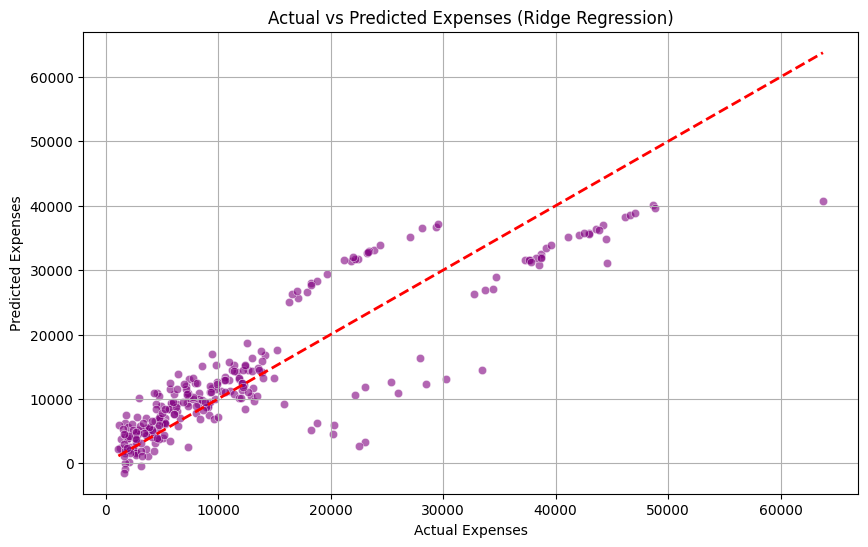

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# رسم النقاط (القيم الحقيقية vs التوقعات)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple')

# رسم خط الـ "Perfect Prediction" (الذي يمثل التوقع المثالي 100%)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Actual vs Predicted Expenses (Ridge Regression)')
plt.xlabel('Actual Expenses')
plt.ylabel('Predicted Expenses')
plt.grid(True)
plt.show()


**Bouns Question:**

by using feature enginering

In [ ]:
# إنشاء ميزة جديدة: مدخن ولديه سمنة
df_final['is_obese_smoker'] = ((df['bmi'] >= 30) & (df['smoker'] == 'yes')).astype(int)
# = 0.87